In [1]:
import pickle
from pathlib import Path

import numpy as np
from tools import tools_file
from tools import tools_augment
from tools import tools_plot
import matplotlib.pyplot as plt

# MOTN file settings
TARGET_HZ = 50.0
MOTN_DIR  = Path(f"Data_Raw/AR/basic trajectory")
SAVE_PATH = Path(f"Data_Processed/AR/ar_trajs_{int(TARGET_HZ)}Hz.pkl")
GRIPPER_WIDTH = 0.085

# Augmenting parameters
AUGMENT_MIRROR_PLANES = ("xz", "yz")
AUGMENT_REVERSE = True
INCLUDE_ORIGINAL = True

motn_files = sorted(MOTN_DIR.rglob("*.motn"))

### **Processing Motn Files**

In [2]:
def motn_to_traj(
    motn_path: Path,
    *,
    target_hz: float | None = TARGET_HZ,
    rot_resample_method: str = "squad",
):
    # .motn file to transform matrix sequence
    ee_tf = tools_file.motn_to_tf(path=motn_path)

    # resampling
    if target_hz is not None:
        ee_tf = tools_file.tfs_resample_tfs([ee_tf], target_fps=target_hz, padding=False)[0]

    # tf to position + axis-angle
    traj = {
        "t": ee_tf["t"].astype(float),
        "ee_tf": ee_tf["tf"],
        "ee_pos": ee_tf["tf"][:, :3, 3],
        "ee_axis_angle": tools_file.rot_to_axis_angle(ee_tf["tf"][:, :3, :3]),
        "gripper_width": ee_tf["gripper_width"],
    }

    return traj


def motn_to_pkl(
    motn_dir: Path,
    save_path: Path,
    *,
    target_hz: float | None = TARGET_HZ,
    rot_resample_method: str = "squad",
    augment_mirror_planes = AUGMENT_MIRROR_PLANES,
    augment_reverse: bool = AUGMENT_REVERSE,
):
    motn_dir = Path(motn_dir)
    save_path = Path(save_path)

    motn_files = sorted(motn_dir.rglob("*.motn"))
    if len(motn_files) == 0:
        raise FileNotFoundError(f"No .motn files found under {motn_dir}")

    data = []
    print("motn files:", len(motn_files))
    print(
        "augmentation:",
        f"mirror_planes={augment_mirror_planes}",
        f"reverse={augment_reverse}",
    )

    for motn_path in motn_files:
        traj = motn_to_traj(
            motn_path,
            target_hz=target_hz,
            rot_resample_method=rot_resample_method,
        )
        variants = tools_augment.augment_traj(
            traj,
            mirror_planes=augment_mirror_planes,
            reverse=augment_reverse,
        )
        data.extend(variants)

        duration = traj["t"][-1]
        fps = round((len(traj["t"]) - 1) / duration, 3) if duration > 0 else 0
        print(
            motn_path.name,
            "frames =", len(traj["t"]),
            "duration =", round(float(duration), 3),
            "fps =", fps,
            "variants =", len(variants),
        )

    save_path.parent.mkdir(parents=True, exist_ok=True)
    with open(save_path, "wb") as f:
        pickle.dump(data, f)

    print("saved:", save_path)
    print("num source trajectories:", len(motn_files))
    print("num saved trajectories:", len(data))
    return data

In [3]:
trajectories = motn_to_pkl(
    MOTN_DIR,
    SAVE_PATH,
    target_hz=TARGET_HZ,
    augment_mirror_planes=AUGMENT_MIRROR_PLANES,
    augment_reverse=AUGMENT_REVERSE,
)

motn files: 99
augmentation: mirror_planes=('xz', 'yz') reverse=True
2026_05_10_1657480430.motn frames = 222 duration = 4.433 fps = 49.85 variants = 8
2026_05_10_1658011620.motn frames = 255 duration = 5.1 fps = 49.804 variants = 8
2026_05_10_1658389050.motn frames = 172 duration = 3.45 fps = 49.565 variants = 8
2026_05_10_1658459530.motn frames = 189 duration = 3.783 fps = 49.692 variants = 8
2026_05_10_1706048040.motn frames = 196 duration = 3.917 fps = 49.787 variants = 8
2026_05_10_1706176230.motn frames = 174 duration = 3.483 fps = 49.665 variants = 8
2026_05_15_1302153920.motn frames = 718 duration = 14.367 fps = 49.907 variants = 8
2026_05_15_1302335290.motn frames = 693 duration = 13.867 fps = 49.904 variants = 8
2026_05_15_1302488140.motn frames = 943 duration = 18.867 fps = 49.929 variants = 8
2026_05_15_1303118720.motn frames = 852 duration = 17.05 fps = 49.912 variants = 8
2026_05_15_1303341740.motn frames = 823 duration = 16.467 fps = 49.919 variants = 8
2026_05_12_1645225

### **Plot Functions**

In [4]:
def load_pkl_trajectories(path=SAVE_PATH):
    with open(path, "rb") as f:
        return pickle.load(f)


def _set_equal_3d_axes(ax, xyz):
    mins = xyz.min(axis=0)
    maxs = xyz.max(axis=0)
    center = (mins + maxs) / 2
    radius = (maxs - mins).max() / 2
    if radius < 1e-8:
        radius = 1e-3

    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    ax.set_box_aspect((1, 1, 1))
    ax.set_proj_type("ortho")


def _apply_3d_view(ax, view):
    match view.lower():
        case "normal":
            pass
        case "top":
            ax.view_init(elev=90, azim=-180)
        case "side":
            ax.view_init(elev=0, azim=-90)
        case "front":
            ax.view_init(elev=0, azim=0)
        case _:
            raise ValueError("3D view must be 'normal', 'top', 'side', or 'front'")


def PLOT_PKL(
    index: int = 0,
    view: str = "xy",
    num: int = 4,
    *,
    data=None,
    pkl_path=SAVE_PATH,
    interval: float = 0.02,
    axis_len: float = 0.04,
    titles=None,
):
    if data is None:
        data = load_pkl_trajectories(pkl_path)

    if index < 0 or index >= len(data):
        raise IndexError(f"index must be in [0, {len(data) - 1}]")

    end = min(index + num, len(data))
    plot_indices = list(range(index, end))
    cols = min(4, len(plot_indices))
    rows = int(np.ceil(len(plot_indices) / cols))

    view = view.lower()


    fig = plt.figure(figsize=(4.5 * cols, 4.5 * rows))

    for plot_id, data_idx in enumerate(plot_indices):
        traj = np.asarray(data[data_idx]["ee_pos"], dtype=float)
        axis_angle = np.asarray(data[data_idx]["ee_axis_angle"], dtype=float)
        step = max(1, int(len(traj) * interval))

        ax = fig.add_subplot(rows, cols, plot_id + 1, projection="3d")
        ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], linewidth=1.5)
        ax.scatter(traj[0, 0], traj[0, 1], traj[0, 2], c="g", marker="o", s=35)
        ax.scatter(traj[-1, 0], traj[-1, 1], traj[-1, 2], c="r", marker="x", s=35)

        # orientation
        for i in range(0, len(traj), step):
            p = traj[i]
            rot = tools_file.axis_angle_to_rot(axis_angle[i])
            ax.quiver(p[0], p[1], p[2], rot[0, 0], rot[1, 0], rot[2, 0], length=axis_len, normalize=True, color="r")
            ax.quiver(p[0], p[1], p[2], rot[0, 1], rot[1, 1], rot[2, 1], length=axis_len, normalize=True, color="g")
            ax.quiver(p[0], p[1], p[2], rot[0, 2], rot[1, 2], rot[2, 2], length=axis_len, normalize=True, color="b")

        _set_equal_3d_axes(ax, traj)
        _apply_3d_view(ax, view)
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")


        if titles is not None and plot_id < len(titles):
            ax.set_title(titles[plot_id])
        else:
            ax.set_title(f"Trajectory index: {data_idx}")

    plt.tight_layout()
    plt.show()


def PLOT_TRAJ_GIF(
    index: int = 0,
    *,
    data=None,
    pkl_path=SAVE_PATH,
    **kwargs,
):
    if data is None:
        data = load_pkl_trajectories(pkl_path)
    return tools_plot.plot_traj_gif(data, index=index, **kwargs)


50


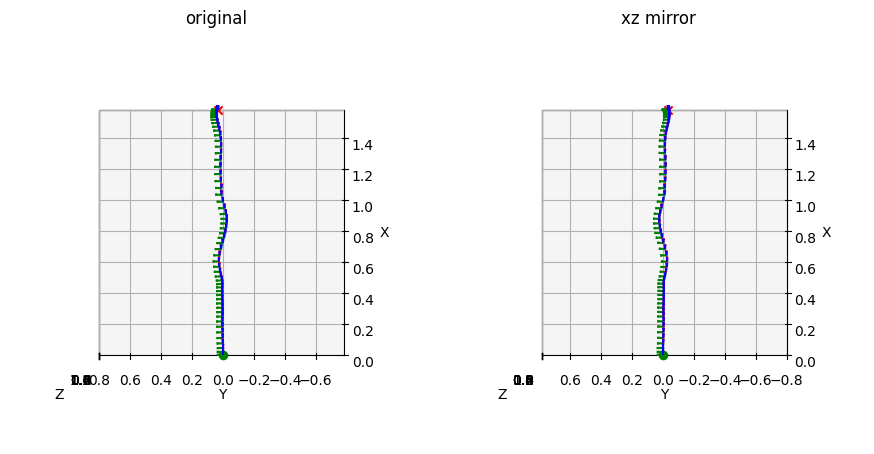

In [5]:
data = tools_file.pkl_to_tf(SAVE_PATH)
print(tools_file.get_fps(data))

PLOT_PKL(
    index=0,
    view="top",
    num=2,
    titles=["original", "xz mirror"],
)

### **Debug Single Trajectory**

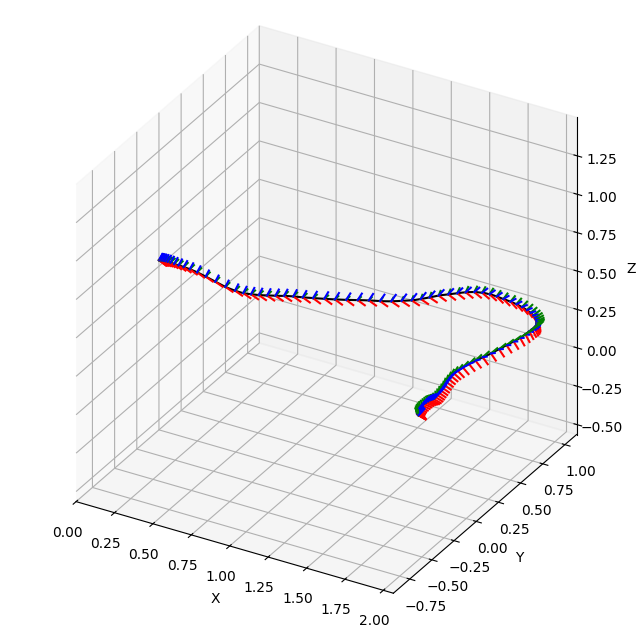

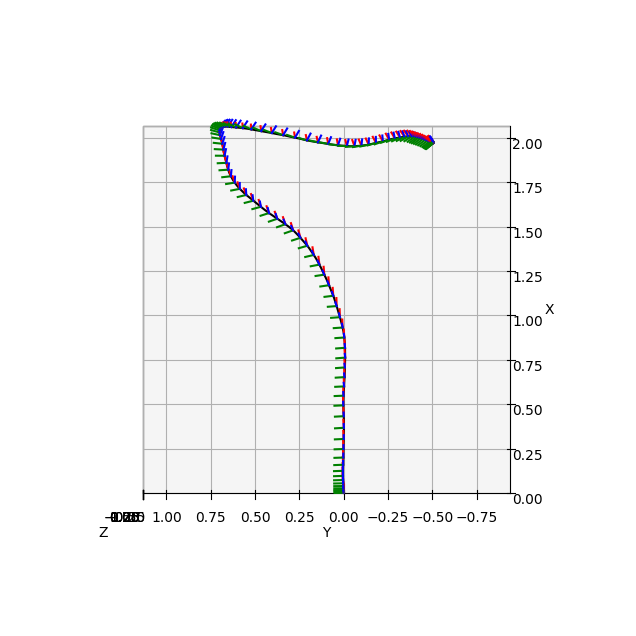

In [6]:
INPUT_PATH = "Data_Raw/AR/basic trajectory/reach_forward/2026_05_10_2135574950/2026_05_10_2135574950.motn"

single_data = tools_file.motn_to_tf(path=INPUT_PATH)

tf = single_data["tf"]

ARROW = 0.05
tools_plot.plot_3d(tf, arrow_length=ARROW, interval=0.01, view="normal")
tools_plot.plot_3d(tf, arrow_length=ARROW, interval=0.01, view="top")

### **Debug Mirror Augmenting**

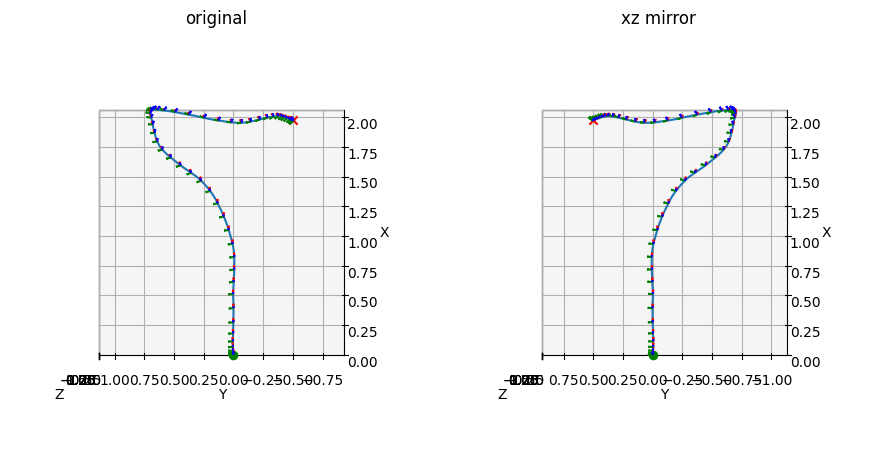

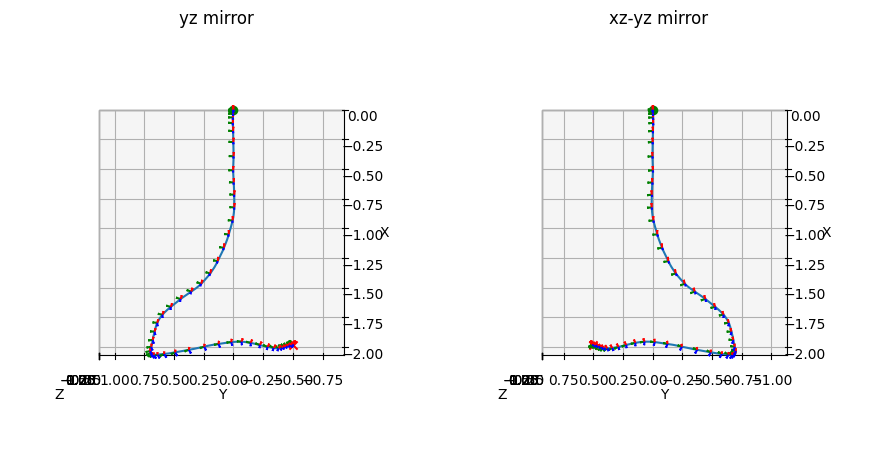

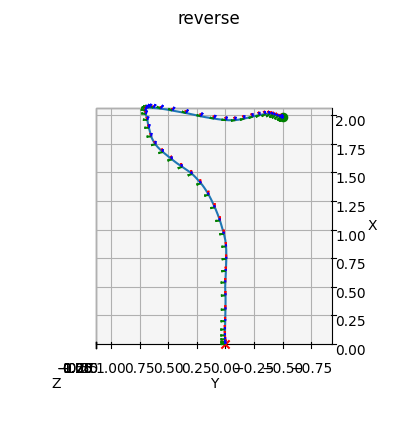

In [7]:
debug_original = motn_to_traj(
    INPUT_PATH,
    target_hz=TARGET_HZ,
)

debug_xz_mirror = tools_augment.mirror_xz_episode(debug_original)
debug_yz_mirror = tools_augment.mirror_yz_episode(debug_original)
debug_xz_yz_mirror = tools_augment.mirror_yz_episode(tools_augment.mirror_xz_episode(debug_original))
debug_backward = tools_augment.reverse_episode(debug_original)

INDEX = 0

PLOT_PKL(
    index=INDEX,
    view="top",
    num=2,
    data=[debug_original, debug_xz_mirror,],
    titles=["original", "xz mirror"],
)

PLOT_PKL(
    index=INDEX,
    view="top",
    num=2,
    data=[debug_yz_mirror, debug_xz_yz_mirror,],
    titles=["yz mirror", "xz-yz mirror"],
)

PLOT_PKL(
    index=INDEX,
    view="top",
    num=2,
    data=[debug_backward,],
    titles=["reverse"],
)

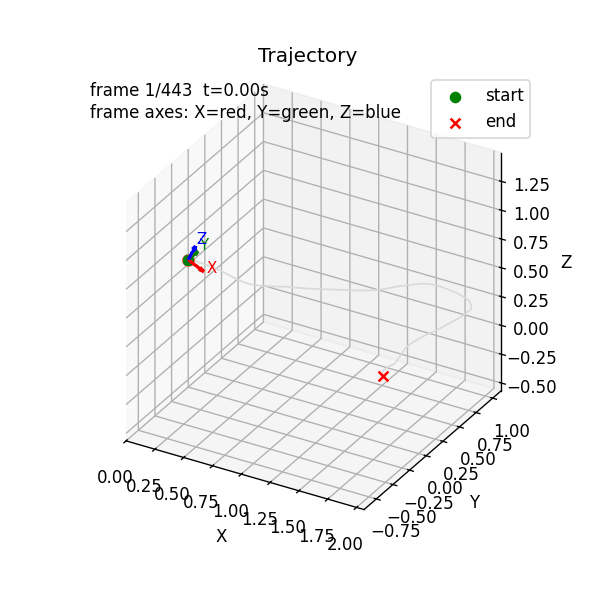

PosixPath('outputs/reach_forward.gif')

In [9]:
tools_plot.plot_traj_gif(
    debug_original,
    save_path="outputs/reach_forward.gif",
    view="normal",
    fps=20,
    stride=10,
    axis_len=0.15,
    show_frame_history=True,
    frame_history_stride=10,
)